# Discrete Fourier Transform (DFT)
In this exercise, we will look at the DFT of **rectangular windows** and **triangular windows** and **compare their performances** as **Low-Pass Filters (LPF)**. 

In [2]:
import numpy as np
from scipy.fft import * 
import matplotlib.pyplot as plt
from scipy.fft import fft, fftshift

# Task-1 
## Q1: Plot the DFT (at least 512 points) of the rectangular window (30 pts)


<center>$$ w[n] = \left \{ \begin{array}{cc} 1 & -N \leq n \leq N \\ 0 & \mathrm{otherwise} \end{array} \right. $$ </center>
				
- Plot the DFT for $ N=5,~20,~100$. 
- **Scale** the DFT so that $W(e^{j0})=1$ in your plots.
- **Label** your plots!
- **Describe** the effect of increasing $N$ on the DFT.


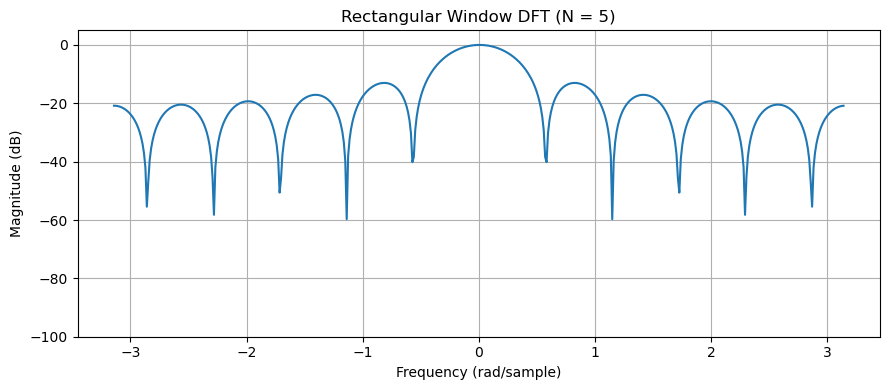

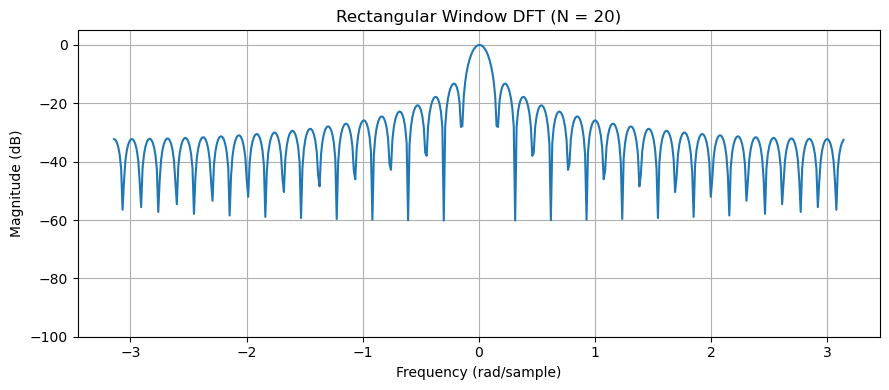

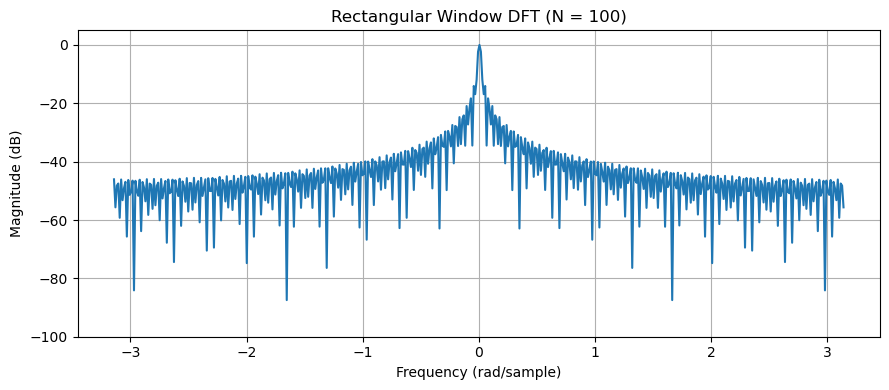

In [3]:
# A1
#repeat for N = 5, 20, 100

fft_len = 512  # FFT uzunluğu

for N in [5, 20, 100]:
    # pencere boyutu: -N ile N arası
    n = np.arange(-N, N+1)

    # dikdörtgen pencere: hepsi 1
    w = np.ones_like(n)

    # frekans dönüşümü
    W = fft(w, fft_len)
    W = fftshift(W)
    W = np.abs(W)

    # normalizasyon
    W /= np.max(W)

    # frekans ekseni -pi'den pi'ye
    freqs = np.linspace(-np.pi, np.pi, fft_len)

    # grafik
    plt.figure(figsize=(9, 4))
    plt.plot(freqs, 20 * np.log10(W + 1e-6))  
    plt.title(f"Rectangular Window DFT (N = {N})")
    plt.xlabel("Frequency (rad/sample)")
    plt.ylabel("Magnitude (dB)")
    plt.ylim([-100, 5])
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## A1: Describe the effect of increasing $N$ on the DFT:



### Effect of Increasing $N$:
Pencere uzunluğu \( N \) arttıkça, DFT'nin ana lobu daralır ve yan loblar daha sıkışık hale gelir. Bu, frekans çözünürlüğünün arttığını gösterir. Ancak yan lobların seviyesi azalmaz, bu daspectral leakage' ın hala var olduğu anlamına gelir. Uzun pencere daha net frekans ayrımı sağlar.


# Task-2 
## Q1: Plot the DFT (at least 512 points) of the triangular window (30 pts)

Repeat part (Task-1) for the triangular window:
$$w_\triangle [n] =  \left ( 1- \frac{|n|}{N} \right ) w[n].$$

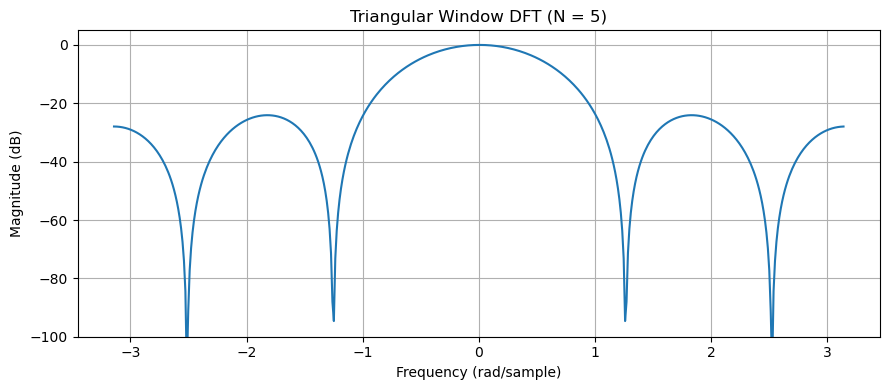

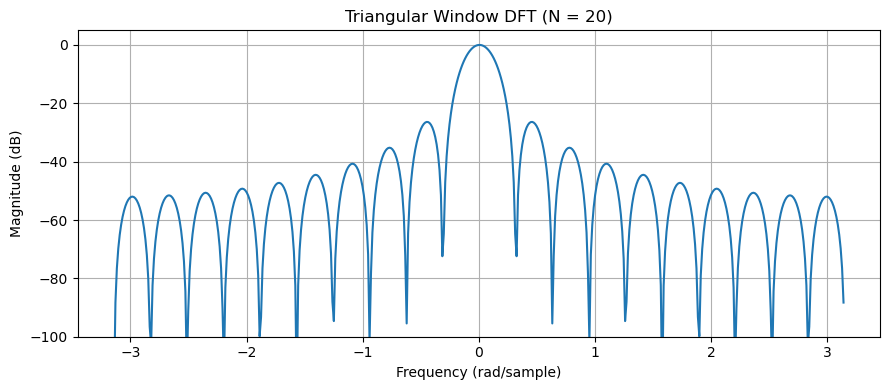

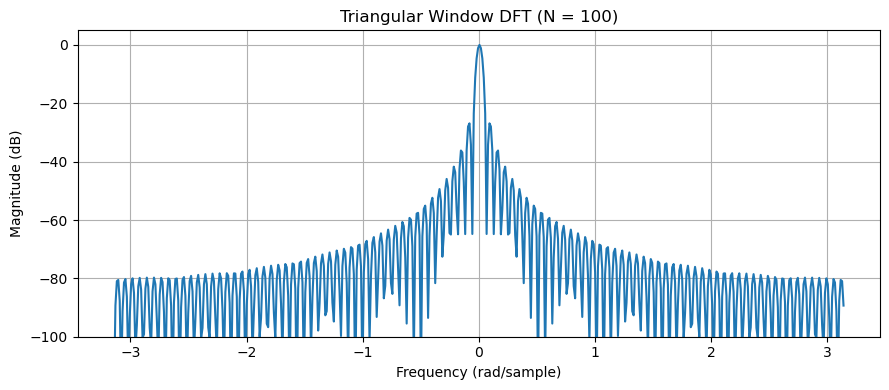

In [4]:
#A2: 

fft_len = 512  # fft uzunluğu

for N in [5, 20, 100]:
    # simetrik eksen
    n = np.arange(-N, N+1)

    # üçgen pencere, tam ortada 1, kenarlara doğru sıfır
    w = 1 - np.abs(n) / N

    # DFT - frekans domainine geçiş
    W = fft(w, fft_len)
    W = fftshift(W)
    W = np.abs(W)

    # normalizasyon
    W /= np.max(W)

    # frekans ekseni -π ile π arası
    freqs = np.linspace(-np.pi, np.pi, fft_len)

    # grafik çizimi
    plt.figure(figsize=(9, 4))
    plt.plot(freqs, 20 * np.log10(W + 1e-6))  
    plt.title(f"Triangular Window DFT (N = {N})")  
    plt.xlabel("Frequency (rad/sample)")
    plt.ylabel("Magnitude (dB)")
    plt.ylim([-100, 5])  # alt sınır sabit
    plt.grid(True)
    plt.tight_layout()
    plt.show()



## A1: Describe the effect of increasing $N$ on the DFT:



### DFT for Triangular Window  

Triangular pencere, dikdörtgen pencereye göre zaman alanında daha yumuşak bir geçişe sahiptir. Üçgen şeklinden ötürü merkezdeki frekansın katkısı daha büyük gelir. Bu nedenle frekans alanında:
- Yan loblar çok daha düşüktür → spectral leakage azalır.
- Ana lob daha geniştir → frekans çözünürlüğü azalır.

\( N \) büyüdükçe:
- Ana lob daralır, daha iyi frekans çözünürlüğü sağlar.
- Yan loblar daha sıkışır ama seviyeleri daha da düşer.
Bu, pencereleme ile çözünürlük-leakage arasında bir denge olduğunu gösterir.


# Task-3 
## Q1: Plot the frequency responses (40 pts)

An **ideal** low-pass filter with cutoff frequency Fc can be characterized by the following ideal frequency response. 

![Lowpass Filter](LPFreq.png)

And its impulse response is given by

![Lowpass filter impulse response](IdealLPFilter.png)

Consider the ideal low-pass filter with cut-off frequency $\omega_c = 0.3 \pi$. **Truncate** the impulse response of this filter using the **windows** in tasks (1) and (2), and **plot** the frequency response of the resulting filters. **Explain** the differences. Don't forget to **label** your plots!

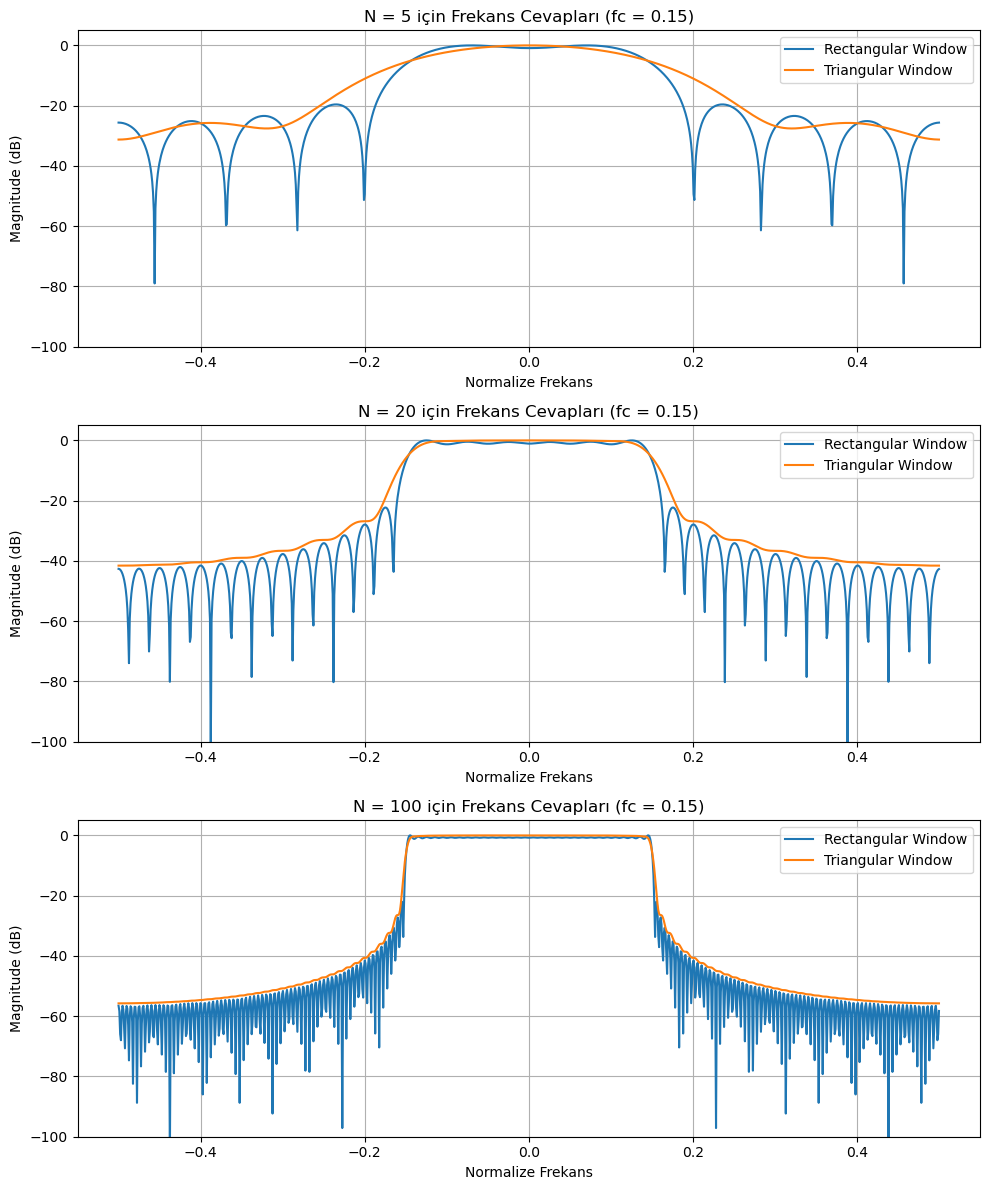

In [5]:
# A3:
# %matplotlib widget

fc = 0.15   # kesim frekansı (normalized)
fft_len = 1024

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 12))  # alt alta 3 grafik

for i, N in enumerate([5, 20, 100]):
    n = np.arange(-N, N + 1)
    h = 2 * fc * np.sinc(2 * fc * n)

    # Rektangüler pencere
    w_rect = np.ones_like(h)
    h_rect = h * w_rect

    # Üçgen pencere
    w_tri = 1 - np.abs(n) / N
    h_tri = h * w_tri

    # Frekans cevabı
    H_rect = np.abs(fftshift(fft(h_rect, fft_len)))
    H_tri = np.abs(fftshift(fft(h_tri, fft_len)))

    H_rect /= np.max(H_rect)
    H_tri /= np.max(H_tri)

    freqs = np.linspace(-0.5, 0.5, fft_len)

    axs[i].plot(freqs, 20 * np.log10(H_rect + 1e-6), label="Rectangular Window")
    axs[i].plot(freqs, 20 * np.log10(H_tri + 1e-6), label="Triangular Window")
    axs[i].set_title(f"N = {N} için Frekans Cevapları (fc = {fc})")
    axs[i].set_xlabel("Normalize Frekans")
    axs[i].set_ylabel("Magnitude (dB)")
    axs[i].set_ylim([-100, 5])
    axs[i].grid(True)
    axs[i].legend()

plt.tight_layout()
plt.show()


## A1: Explain the difference


###  Ideal LPF with Windowing
Sırasıyla 11 41 ve 201 örnekle oluşturduğumuz ideal LPF' de;
- **N sayısı** arttıkça window ve filtrenin daha keskinleştiğini ancak çok da fazla örnek kullanıldığından işlem süresi uzar.
- **Rectangular window** ani kesim yaptığı için frekans alanında sızıntı (leakage) oluşturur. Bu, yüksek yan loblara neden olur.
- **Triangular window** zaman alanında yumuşak geçiş yapar → yan loblar ciddi oranda bastırılır.
- Ancak: Triangular window daha geniş ana lobe sahiptir → frekans çözünürlüğü biraz düşer.

**Sonuç:**  
Rectangular → Daha iyi çözünürlük ama daha fazla leakage.  
Triangular → Daha az leakage ama daha az çözünürlük.
